<a href="https://colab.research.google.com/github/AkashMR98/Emergency-Department-Volume-and-Capacity/blob/main/Python%20ED%20Volume%20and%20Capacity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Emergency Department Volume and Capacity**

#**Business Problem**

Healthcare systems often face challenges in managing emergency department demand due to increasing patient volume and limited resources.

Hospitals need to answer critical questions like:

1. Are emergency departments overloaded?

2. Do hospitals have enough beds and treatment stations?

3. Which regions are facing higher patient demand?

4. Are there shortages in healthcare facilities (primary care / mental health)?

5. How can resources be optimized to reduce patient wait times?

Without proper analysis, hospitals may experience overcrowding, delayed treatments, and inefficient resource allocation.

# **Dataset Information**

Source : https://catalog.data.gov/dataset/emergency-department-volume-and-capacity?from_hint=eyJzb3J0IjoicG9wdWxhcml0eSIsInEiOiIiLCJzcGF0aWFsX2ZpbHRlciI6IiJ9

Location : United States (hospital-level emergency department data across multiple states)

Year/Timeline : 2021 - 2023

Domain : Healthcare Analytics / Hospital Management / Public Health

Dataset Size

Number of Records (Rows): 12,000+

Number of Attributes (Columns): 18



# **Objective**

The main objectives of this project are:

1. To analyze patient volume across different hospitals and identify high-demand facilities

2. To evaluate hospital capacity by comparing patient visits with available beds and ED stations

3. To measure resource utilization and detect overcrowding in emergency departments

4. To analyze regional differences in patient demand (urban vs rural areas)

5. To identify shortages in primary care and mental health services

6. To study trends in emergency department visits over time

7. To provide data-driven insights for improving hospital efficiency and resource allocation

#**Attributes and Description**

| Attributes               | Description                                       |
| ------------------------ | ------------------------------------------------- |
| oshpd_id                 | OSHPD ID for the facility                         |
| FacilityName2            | Name of the facility                              |
| CountyName               | County the facility is located in                 |
| system                   | Hospital system the facility is part of           |
| LICENSED_BED_SIZE        | Category (range) of ED treatment stations         |
| HospitalOwnership        | Facility ownership category                       |
| UrbanRuralDesi           | Urban or rural designation of the facility        |
| TEACHINGDesignation      | Indicates if facility is teaching or non-teaching |
| Category                 | Health-related condition category                 |
| Tot_ED_NmbVsts           | Total number of ED encounters                     |
| EDStations               | Number of ED treatment stations                   |
| EDDXCount                | Number of ED visits for the specific category     |
| LATITUDE                 | Facility latitude                                 |
| LONGITUDE                | Facility longitude                                |
| PrimaryCareShortageArea  | Indicates if in Primary Care shortage area        |
| MentalHealthShortageArea | Indicates if in Mental Health shortage area       |
| Visits_Per_Station       | Number of ED visits per station                   |
| Year                     | Year of the data                                  |


#**Excepted Outcome**

* Identify high patient demand in emergency departments

* Understand hospital capacity and resource utilization

* Detect shortages in healthcare services

* Provide insights to improve efficiency and reduce waiting time

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# Load the Data Set from GitHub
url = "https://raw.githubusercontent.com/AkashMR98/Emergency-Department-Volume-and-Capacity/refs/heads/main/DATA%20ED/emergency%20department%20volume-and-capacity-2021-2023.csv"

df = pd.read_csv(url)

In [ ]:
df

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.762660,-122.253991,No,No,43.333333
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.856450,-122.257430,No,No,53.500000
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.837220,-122.267470,No,No,45.550000
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.799250,-122.231380,No,No,39.792453
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.821060,-122.262570,No,No,44.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,106560525,Adventist Health Simi Valley,Ventura,Adventist Health Systems,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,34.289730,-118.743940,No,No,106.777778
12845,106560529,St. John's Regional Medical Center,Ventura,Dignity Health,2021,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,34.216870,-119.158190,No,Yes,86.387097
12846,106571086,Woodland Memorial Hospital,Yolo,Dignity Health,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,38.662840,-121.793300,No,Yes,73.176471
12847,106574010,Sutter Davis Hospital,Yolo,Sutter Health,2021,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,38.562890,-121.771640,No,Yes,105.636364


In [ ]:
#  Data Types & Info
print("\n Dataset Info:")
df.info()


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   oshpd_id                  12849 non-null  int64  
 1   FacilityName2             12849 non-null  object 
 2   CountyName                12849 non-null  object 
 3   system                    9259 non-null   object 
 4   year                      12849 non-null  int64  
 5   LICENSED_BED_SIZE         12849 non-null  object 
 6   HospitalOwnership         12849 non-null  object 
 7   UrbanRuralDesi            12849 non-null  object 
 8   TEACHINGDesignation       12849 non-null  object 
 9   Category                  12849 non-null  object 
 10  Tot_ED_NmbVsts            12849 non-null  int64  
 11  EDStations                12832 non-null  float64
 12  EDDXCount                 12849 non-null  int64  
 13  LATITUDE                  12849 non-null  flo

In [ ]:
#  First 5 Rows
print("\n First 5 Rows:")
display(df.head())


 First 5 Rows:


,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.76266,-122.253991,No,No,43.333333
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.85645,-122.257430,No,No,53.500000
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.83722,-122.267470,No,No,45.550000
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.79925,-122.231380,No,No,39.792453
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.82106,-122.262570,No,No,44.166667


In [ ]:
# Last 5 Rows
print("\n Last 5 Rows:")
display(df.tail())


 Last 5 Rows:


,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
12844,106560525,Adventist Health Simi Valley,Ventura,Adventist Health Systems,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,34.289730,-118.743940,No,No,106.777778
12845,106560529,St. John's Regional Medical Center,Ventura,Dignity Health,2021,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,34.216870,-119.158190,No,Yes,86.387097
12846,106571086,Woodland Memorial Hospital,Yolo,Dignity Health,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,38.662840,-121.793300,No,Yes,73.176471
12847,106574010,Sutter Davis Hospital,Yolo,Sutter Health,2021,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,38.562890,-121.771640,No,Yes,105.636364
12848,106580996,Adventist Health and Rideout,Yuba,Adventist Health Systems,2021,200-299,Nonprofit,Rural,Non-Teaching,Substance Abuse,55341,44.0,3942,39.138805,-121.593602,Yes,Yes,89.590909


In [ ]:
#  Column Names
print("\n Column Names:")
print(df.columns)


 Column Names:
Index(['oshpd_id', 'FacilityName2', 'CountyName', 'system', 'year',
       'LICENSED_BED_SIZE', 'HospitalOwnership', 'UrbanRuralDesi',
       'TEACHINGDesignation', 'Category', 'Tot_ED_NmbVsts', 'EDStations',
       'EDDXCount', 'LATITUDE', 'LONGITUDE', 'PrimaryCareShortageArea',
       'MentalHealthShortageArea', 'Visits_Per_Station'],
      dtype='object')


In [ ]:
#  Statistical Summary
print("\n Statistical Summary:")
display(df.describe())


 Statistical Summary:


,oshpd_id,year,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,Visits_Per_Station
count,1.284900e+04,12849.000000,12849.000000,12832.000000,12849.000000,12849.000000,12849.000000,12832.000000
mean,1.062833e+08,2022.006226,39642.067632,28.596088,3756.252004,35.987183,-119.749849,138.749681
std,1.387678e+05,0.812108,26917.290211,20.756854,11414.191936,2.241393,2.055228,376.131473
min,1.060107e+08,2021.000000,511.000000,1.000000,0.000000,32.619090,-124.195140,0.000000
25%,1.061904e+08,2021.000000,18962.000000,12.000000,93.000000,34.026260,-121.802690,5.111111
50%,1.063012e+08,2022.000000,33711.000000,24.000000,513.000000,35.372801,-119.263110,22.869318
75%,1.063809e+08,2023.000000,54542.000000,40.000000,2133.000000,37.821060,-118.049255,84.265873
max,1.065810e+08,2023.000000,146799.000000,114.000000,146799.000000,41.773659,-114.595600,4714.000000


In [ ]:
#  Unique Values (Categorical Columns)
print("\n Unique Values Count:")
for col in df.columns:
    print(col, ":", df[col].nunique())


 Unique Values Count:
oshpd_id : 297
FacilityName2 : 315
CountyName : 53
system : 31
year : 3
LICENSED_BED_SIZE : 7
HospitalOwnership : 3
UrbanRuralDesi : 3
TEACHINGDesignation : 2
Category : 17
Tot_ED_NmbVsts : 754
EDStations : 80
EDDXCount : 4634
LATITUDE : 538
LONGITUDE : 538
PrimaryCareShortageArea : 2
MentalHealthShortageArea : 2
Visits_Per_Station : 9160


#**Data Cleaning, Transformation**

In [ ]:
# Rename Columns
df.rename(columns={
    'oshpd_id': 'hospital_id',
    'FacilityName2': 'hospital_name',
    'CountyName': 'county',
    'system': 'hospital_system',
    'LICENSED_BED_SIZE': 'bed_size',
    'HospitalOwnership': 'ownership',
    'UrbanRuralDesi': 'area_type',
    'TEACHINGDesignation': 'teaching_status',
    'Category': 'condition',
    'Tot_ED_NmbVsts': 'total_visits',
    'EDStations': 'ed_stations',
    'EDDXCount': 'condition_visits',
    'LATITUDE': 'latitude',
    'LONGITUDE': 'longitude',
    'PrimaryCareShortageArea': 'primary_care_area',
    'MentalHealthShortageArea': 'mental_health_area',
    'Visits_Per_Station': 'visits_per_station',
    'Year': 'year'
}, inplace=True)
df.columns

Index(['hospital_id', 'hospital_name', 'county', 'hospital_system', 'year',
       'bed_size', 'ownership', 'area_type', 'teaching_status', 'condition',
       'total_visits', 'ed_stations', 'condition_visits', 'latitude',
       'longitude', 'primary_care_area', 'mental_health_area',
       'visits_per_station'],
      dtype='object')

In [ ]:
#  Duplicate Values
print("\n Duplicate Rows:")
print(df.duplicated().sum())


 Duplicate Rows:
0


In [ ]:
# Missing Values
print("\n Missing Values:")
print(df.isnull().sum())


 Missing Values:
oshpd_id                       0
FacilityName2                  0
County                         0
system                      3590
year                           0
LICENSED_BED_SIZE              0
Ownership                      0
UrbanRuralDesi                 0
TEACHINGDesignation            0
Category                       0
Tot_ED_NmbVsts                 0
EDStations                    17
EDDXCount                      0
LATITUDE                       0
LONGITUDE                      0
PrimaryCareShortageArea        0
MentalHealthShortageArea       0
Visits_Per_Station            17
dtype: int64


In [ ]:
#Handle the missing value
df['hospital_system'] = df['hospital_system'].fillna('Unknown')
df['ed_stations'] = df['ed_stations'].fillna(df['ed_stations'].median())
df['visits_per_station'] = df['visits_per_station'].fillna(df['visits_per_station'].median())

In [ ]:
#Recheck the missing value
print("\n Recheck the missing values:")
print(df.isnull().sum())


 Recheck the missing values:
oshpd_id                    0
FacilityName2               0
County                      0
system                      0
year                        0
LICENSED_BED_SIZE           0
Ownership                   0
UrbanRuralDesi              0
TEACHINGDesignation         0
Category                    0
Tot_ED_NmbVsts              0
EDStations                  0
EDDXCount                   0
LATITUDE                    0
LONGITUDE                   0
PrimaryCareShortageArea     0
MentalHealthShortageArea    0
Visits_Per_Station          0
dtype: int64


# **Feature Engineering**

In [ ]:
# Are emergency departments overloaded?
df['load_per_station'] = df['total_visits'] / df['ed_stations']

# Check average load
avg_load = df['load_per_station'].mean()
print("Average Load per Station:", avg_load)

# High load hospitals
overloaded = df[df['load_per_station'] > avg_load]
print("Overloaded hospitals count:", len(overloaded))

Average Load per Station: 1486.4627663145927
Overloaded hospitals count: 5590


In [ ]:
def convert_bed_size(x):

    x = str(x).strip()

    #  Range (e.g., 100-149)
    if '-' in x:
        low, high = x.split('-')
        return round(int(low) + int(high)) / 2

    #  500+
    elif '+' in x:
        return int(x.replace('+', ''))  # 500+

    #  Normal number
    else:
        return int(x)


In [ ]:
df['bed_size_numeric'] = df['bed_size'].apply(convert_bed_size)

In [ ]:
# Do hospitals have enough beds and treatment stations?

df['patients_per_bed'] = df['total_visits'] / df['bed_size_numeric']
print(df['patients_per_bed'].describe())

count    12849.000000
mean       236.685492
std        200.685400
min         13.012048
25%        113.617021
50%        183.892617
75%        289.078156
max       1532.760000
Name: patients_per_bed, dtype: float64


In [ ]:
# Which regions are facing higher patient demand?

region_demand = df.groupby('county')['total_visits'].sum().sort_values(ascending=False)
print(region_demand.head(10))

county
Los Angeles       122244600
San Diego          33911668
Orange             31651754
San Bernardino     29903068
Riverside          29475569
Alameda            24260733
Sacramento         22199042
Santa Clara        19060179
San Joaquin        15753322
Fresno             14624819
Name: total_visits, dtype: int64


In [ ]:
# Are there shortages in healthcare facilities?

# Primary care shortage
primary_shortage = df['primary_care_area'].value_counts()

# Mental health shortage
mental_shortage = df['mental_health_area'].value_counts()

print(primary_shortage)
print(mental_shortage)

primary_care_area
No     8865
Yes    3984
Name: count, dtype: int64
mental_health_area
No     7687
Yes    5162
Name: count, dtype: int64


In [ ]:
# How can resources be optimized?

# Identify high load hospitals
high_load = df[df['load_per_station'] > df['load_per_station'].mean()]

# Sort to prioritize
high_load = high_load.sort_values(by='load_per_station', ascending=False)

print(high_load[['hospital_name', 'county', 'load_per_station']].head(10))

                      hospital_name       county  load_per_station
4254   St. Louise Regional Hospital  Santa Clara            4714.0
8789   St. Louise Regional Hospital  Santa Clara            4714.0
2744   St. Louise Regional Hospital  Santa Clara            4714.0
3498   St. Louise Regional Hospital  Santa Clara            4714.0
9546   St. Louise Regional Hospital  Santa Clara            4714.0
8032   St. Louise Regional Hospital  Santa Clara            4714.0
5007   St. Louise Regional Hospital  Santa Clara            4714.0
12567  St. Louise Regional Hospital  Santa Clara            4714.0
475    St. Louise Regional Hospital  Santa Clara            4714.0
6519   St. Louise Regional Hospital  Santa Clara            4714.0


In [ ]:
# Basic Info
print("\n Basic Info:")
df.info()
df.describe()


 Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hospital_id         12849 non-null  int64  
 1   hospital_name       12849 non-null  object 
 2   county              12849 non-null  object 
 3   hospital_system     12849 non-null  object 
 4   year                12849 non-null  int64  
 5   bed_size            12849 non-null  object 
 6   ownership           12849 non-null  object 
 7   area_type           12849 non-null  object 
 8   teaching_status     12849 non-null  object 
 9   condition           12849 non-null  object 
 10  total_visits        12849 non-null  int64  
 11  ed_stations         12849 non-null  float64
 12  condition_visits    12849 non-null  int64  
 13  latitude            12849 non-null  float64
 14  longitude           12849 non-null  float64
 15  primary_care_area   12849 non-null  obj

,hospital_id,year,total_visits,ed_stations,condition_visits,latitude,longitude,visits_per_station,bed_size_numeric,patients_per_bed,load_per_station
count,1.284900e+04,12849.000000,12849.000000,12849.000000,12849.000000,12849.000000,12849.000000,12849.000000,12849.000000,12849.000000,12849.000000
mean,1.062833e+08,2022.006226,39642.067632,28.590007,3756.252004,35.987183,-119.749849,138.596364,220.777998,236.681687,1486.462766
std,1.387678e+05,0.812108,26917.290211,20.743790,11414.191936,2.241393,2.055228,375.906152,140.581073,200.692456,597.270143
min,1.060107e+08,2021.000000,511.000000,1.000000,0.000000,32.619090,-124.195140,0.000000,25.000000,13.000000,166.623188
25%,1.061904e+08,2021.000000,18962.000000,12.000000,93.000000,34.026260,-121.802690,5.125000,124.500000,114.000000,1078.304348
50%,1.063012e+08,2022.000000,33711.000000,24.000000,513.000000,35.372801,-119.263110,22.869318,174.500000,184.000000,1384.307692
75%,1.063809e+08,2023.000000,54542.000000,39.000000,2133.000000,37.821060,-118.049255,84.206897,399.500000,289.000000,1750.800000
max,1.065810e+08,2023.000000,146799.000000,114.000000,146799.000000,41.773659,-114.595600,4714.000000,500.000000,1533.000000,4714.000000



 Distribution:


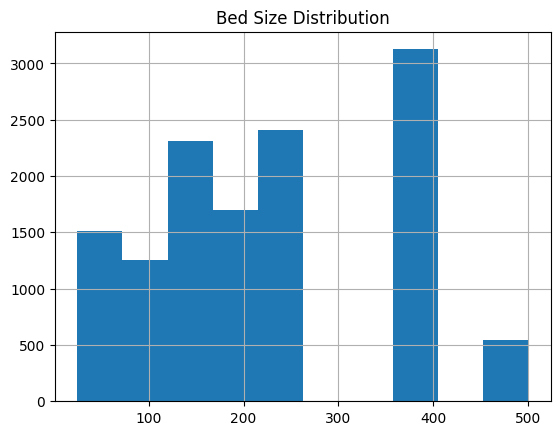

In [ ]:
# Distribution

print("\n Distribution:")
df['bed_size_numeric'].hist()
plt.title("Bed Size Distribution")
plt.show()


 Outliers Check:


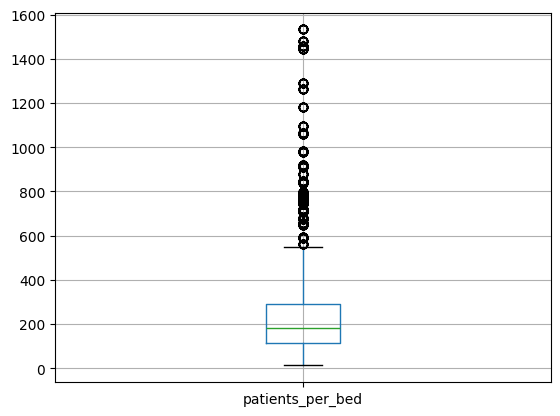

In [ ]:
# Outliers Check

print("\n Outliers Check:")
df.boxplot(column='patients_per_bed')
plt.show()

In [ ]:
# Top Hospitals by Visits

print("\n Top Hospitals by Visits:")
df.groupby('hospital_name')['total_visits']\
    .sum()\
    .sort_values(ascending=False)\
    .head(10)


 Top Hospitals by Visits:


,total_visits
hospital_name,
Kaiser Foundation Hospital – Fontana,7243394
Kaiser Foundation Hospital – Roseville,6180333
Kaiser Foundation Hospital – San Diego – Zion,5814051
Kaiser Foundation Hospital – Orange County – Anaheim,5693912
Kaiser Foundation Hospital – South Sacramento,5431177
Kaiser Foundation Hospital – Manteca,5296418
Hoag Memorial Hospital Presbyterian,5149249
Scripps Mercy Hospital,4945045
Kaiser Foundation Hospital – Sacramento,4942512


In [ ]:
# Urban vs Rural vs Frontier Comparison

df.groupby('area_type')['total_visits'].mean()

,total_visits
area_type,
Frontier,3941.727979
Rural,20881.271686
Urban,45593.930732


In [ ]:
# Health System Analysis

df.groupby('hospital_system')['total_visits']\
    .sum()\
    .sort_values(ascending=False)\
    .head(10)

,total_visits
hospital_system,
Unknown,116426047
Kaiser Foundation Hospitals,110661772
Dignity Health,43501657
Sutter Health,32697553
Providence St. Joseph Health,30610200
Adventist Health Systems,25940249
Tenet Healthcare Corporation,18784490
Prime Healthcare Services,13319024
"Universal Health Services, Inc.",11977095


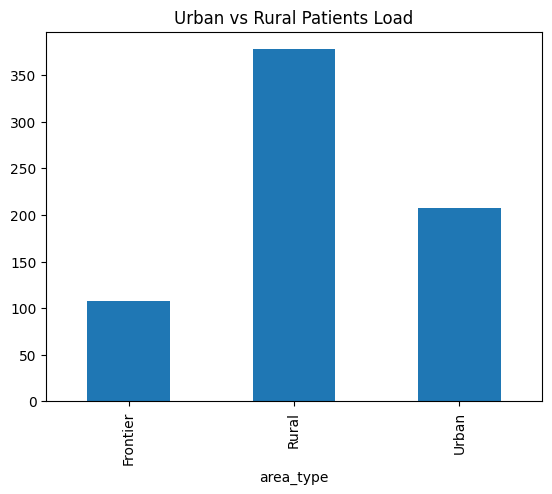

In [ ]:
# Area Type vs Average Patients

df.groupby('area_type')['patients_per_bed'].mean().plot(kind='bar')
plt.title("Urban vs Rural Patients Load")
plt.show()

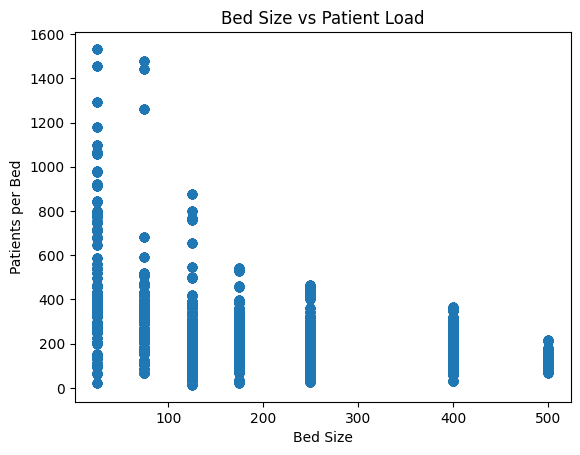

In [ ]:
# Bed Size vs Patients Load

plt.scatter(df['bed_size_numeric'], df['patients_per_bed'])
plt.xlabel("Bed Size")
plt.ylabel("Patients per Bed")
plt.title("Bed Size vs Patient Load")
plt.show()

# **Statistical analysis & Visualizations**

In [ ]:
# MEASURE OF CENTRAL TENDENCY + Chart

df['total_visits'].mean()
df['total_visits'].median()
df['total_visits'].mode()

,total_visits
0,22161
1,26503
2,27691


In [ ]:
# Variance and Standard Deviation

df['total_visits'].var()
df['total_visits'].std()

26917.290210821946

# Interpretation:

Metric: Variance & Standard Deviation

What it shows: Spread of patient visits

Insight: Visits vary a lot across hospitals

Business: Uneven load → need better resource planning

# **1. Univariate Analysis**

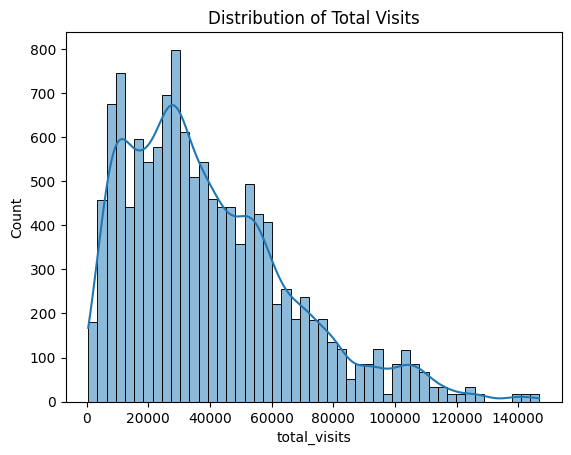

In [ ]:
#Distribution of Total Visits

sns.histplot(df['total_visits'], kde=True)
plt.title("Distribution of Total Visits")
plt.show()

# Interpretation:

Column used: total_visits

What it shows: Total ED patient count

Insight: Most hospitals have moderate visits

Business: Helps in staffing & capacity planning

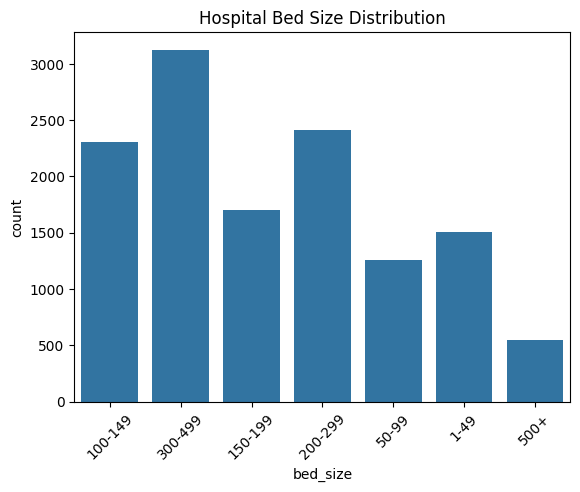

In [ ]:
# Hospital Bed Size Distribution

sns.countplot(x=df['bed_size'])
plt.title("Hospital Bed Size Distribution")
plt.xticks(rotation=45)
plt.show()


# **interpretation**

Column used: bed_size

What it shows: Distribution of hospital sizes

Insight: Most hospitals are medium-sized (300–499 beds), very large hospitals are fewer

Business: Helps in capacity planning and resource allocation

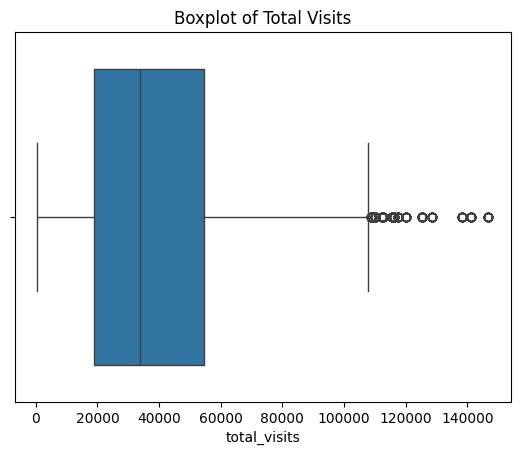

In [ ]:
#Outlier Detection in Patient Visits

sns.boxplot(x=df['total_visits'])
plt.title("Boxplot of Total Visits")
plt.show()

# **Interpertation**

Column used: total_visits

What it shows: Distribution and spread of patient visits across hospitals (including outliers)

Insight: Most hospitals have moderate visits, but a few hospitals have extremely high visits (outliers)

Business: Helps identify high-demand hospitals and plan staffing/resources accordingly

# **2. Bivariate Analysis**

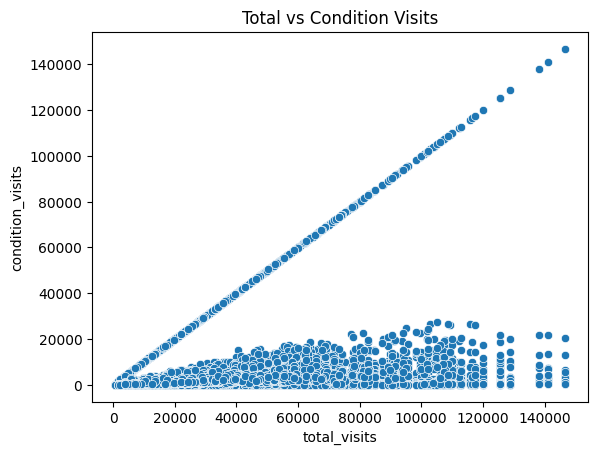

In [ ]:
# Total Visits vs Condition Visits

ns.scatterplot(x='total_visits', y='condition_visits', data=df)
plt.title("Total vs Condition Visits")
plt.show()

# **Interpretation**


Column Used : total_visits, condition_visits

What it shows : Relation between total & condition visits

Insight : Condition visits < total visits, positive trend

Business : Improve condition conversion


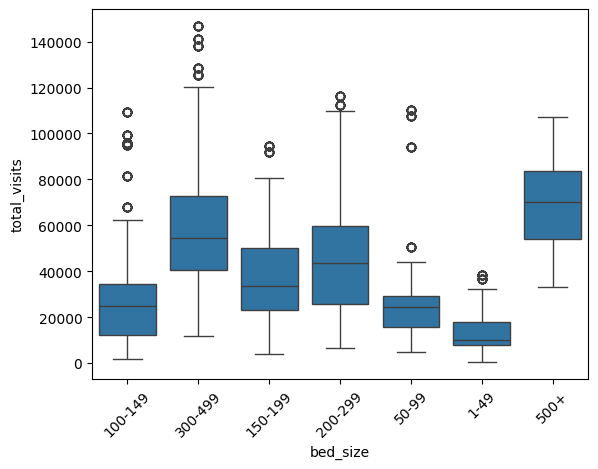

In [ ]:
# Bed Size vs Total Visits

sns.boxplot(x='bed_size', y='total_visits', data=df)
plt.xticks(rotation=45)
plt.show()

# **Interpretation**

Column Used : bed_size, total_visits

What it shows : Visits distribution across bed sizes

Insight : Larger bed size → more visits

Business : Focus on high bed-size hospitals

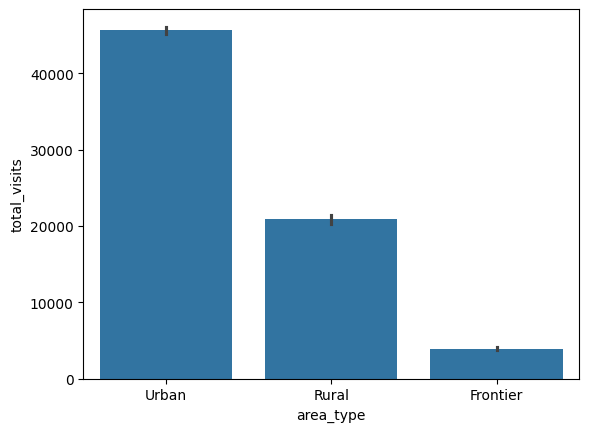

In [ ]:
# Area Type vs Total Visits

sns.barplot(x='area_type', y='total_visits', data=df)
plt.show()

# **Interpretation**

Column Used : area_type, total_visits

What it shows : Visits by area type

Insight : Urban has highest visits, Rural is medium, Frontier is lowest

Business : Focus more on rural & frontier growth

# **3. Multivariate Analysis**


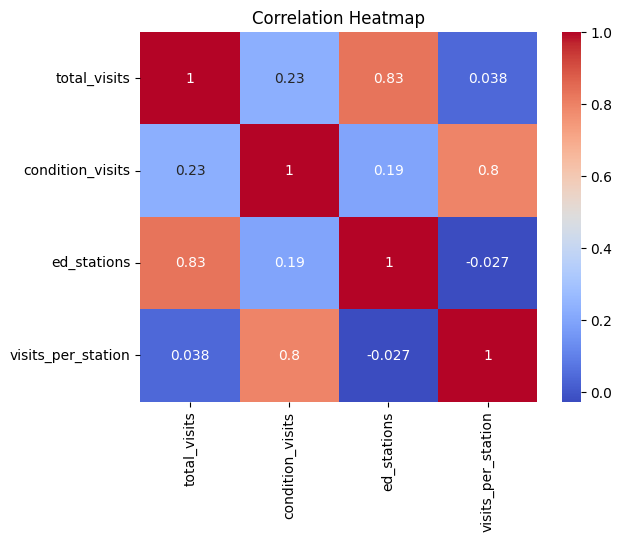

In [ ]:
# Correlation Heatmap

corr = df[['total_visits', 'condition_visits', 'ed_stations', 'visits_per_station']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Interpretation**

Column Used : total_visits, condition_visits, ed_stations, visits_per_station

What it shows : Correlation between variables

Insight : Strong relation: total_visits & ed_stations, condition_visits & visits_per_station

Business : Increase stations to grow visits


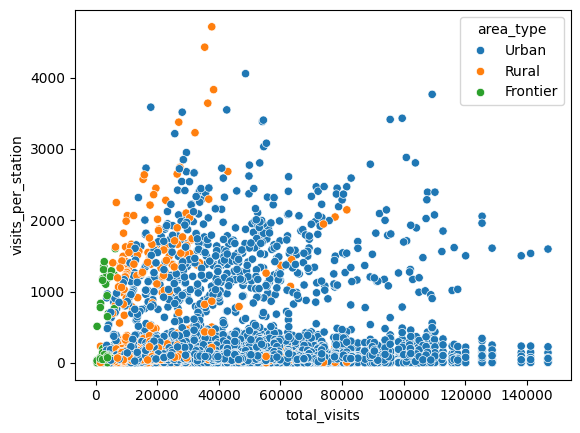

In [ ]:
# Scatter (with hue)

sns.scatterplot(x='total_visits', y='visits_per_station', hue='area_type', data=df)
plt.show()

# **Interpretation**

Column used : total_visits (X-axis),visits_per_station (Y-axis),area_type (hue / category)

What it shows :
1. Total visits vs visits per station relationship
2. Area type (Urban, Rural, Frontier) distribution

Insight :
1. Urban → high visits spread (more usage)

2. Rural → medium range

3. Frontier → low visits mostly

4. Weak positive trend (visits → station usage slightly)

Business :

1. Urban areas → more stations / optimize load

2. Rural → moderate expansion

3. Frontier → low demand → cost control / selective growth